<a href="https://colab.research.google.com/github/KarineMuradyan/University_OptimizationMethods/blob/main/lab2_Dichotomous%20Search/Personal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Accurate Solution (using SciPy) ---
Exact Minimum Point (x*): 1.1572
Exact Minimum Value f(x*): -0.6609
Iter  a          b          x1         x2         f(x1)      f(x2)     
---------------------------------------------------------------------------
0     0.0000     3.0000     1.4375     1.5625     -0.5711    -0.4740   
1     0.0000     1.5625     0.7188     0.8438     -0.4335    -0.5455   
2     0.7188     1.5625     1.0781     1.2031     -0.6537    -0.6585   
---------------------------------------------------------------------------
Final Minimum Point: x* ≈ 1.3203
Function Value at Minimum: f(x*) ≈ -0.6303


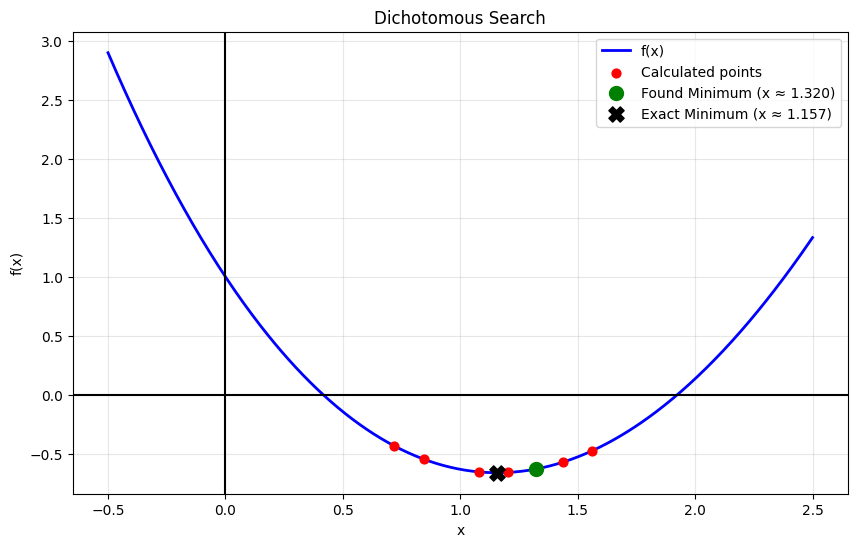

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 1. Objective function
def f(x):
    return np.e**(-x)+x**2-2*x
# 1. Accurate Solution (using SciPy)
res = minimize(f, x0=1.5)
x_star = res.x[0]
f_star = res.fun

print("--- Accurate Solution (using SciPy) ---")
print(f"Exact Minimum Point (x*): {x_star:.4f}")
print(f"Exact Minimum Value f(x*): {f_star:.4f}")

# Parameters
a = 0
b = 3
epsilon = 0.5
delta = 0.125
all_x = []
all_y = []

# Table Header
print(f"{'Iter':<5} {'a':<10} {'b':<10} {'x1':<10} {'x2':<10} {'f(x1)':<10} {'f(x2)':<10}")
print("-" * 75)

# 2. Dichotomous Search Method with Step-by-Step Output
k = 0
while (b - a) > epsilon:
    x1 = (a + b - delta) / 2
    x2 = (a + b + delta) / 2
    f1, f2 = f(x1), f(x2)

    # Store for plotting
    all_x.extend([x1, x2])
    all_y.extend([f1, f2])

    # Print current step results
    print(f"{k:<5} {a:<10.4f} {b:<10.4f} {x1:<10.4f} {x2:<10.4f} {f1:<10.4f} {f2:<10.4f}")

    if f1 <= f2:
        b = x2
    else:
        a = x1
    k += 1

# Final Result
x_star = (a + b) / 2
print("-" * 75)
print(f"Final Minimum Point: x* ≈ {x_star:.4f}")
print(f"Function Value at Minimum: f(x*) ≈ {f(x_star):.4f}")

# 3. Visualization (modified for colors & axes)
x_vals = np.linspace(-0.5, 2.5, 500)
plt.figure(figsize=(10, 6))
plt.plot(x_vals, f(x_vals), label='f(x)', color='blue', linewidth=2)

# Calculated points from dichotomous search
plt.scatter(all_x, all_y, color='red', s=40, zorder=5, label='Calculated points')

# Your found minimum
plt.scatter(x_star, f(x_star), s=100, color='green', zorder=6, label=f'Found Minimum (x ≈ {x_star:.3f})')

# Exact minimum from SciPy
plt.scatter(res.x[0], res.fun, s=120, marker='X', color='black', zorder=7, label=f'Exact Minimum (x ≈ {res.x[0]:.3f})')

# Draw clear coordinate axes
plt.axhline(0, color='black', linewidth=1.5)
plt.axvline(0, color='black', linewidth=1.5)

plt.title('Dichotomous Search')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()